In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
df = pd.read_csv('/content/PCOS_extended_dataset.csv')

In [ ]:
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,193,193,0,30,69.979147,167.708055,23.185569,12,72,22,...,1,0.0,1,105.483401,76.096379,2,4,10.0,13.0,6.176029
1,360,360,0,36,63.711688,154.055877,25.441392,13,70,18,...,1,0.0,1,115.883740,79.117243,2,3,13.0,11.0,6.824718
2,10,10,0,36,51.848631,149.059804,23.928264,15,80,20,...,0,0.0,0,112.219711,80.919417,1,1,14.0,17.0,2.568691
3,278,278,1,29,66.893988,148.628036,27.894935,15,72,18,...,0,0.0,1,104.619624,69.902681,1,1,12.0,14.0,9.962732
4,71,71,0,33,52.536198,150.767409,23.079564,13,72,18,...,0,0.0,0,99.175454,70.330461,5,2,11.5,4.7,6.655190


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  2000 non-null   int64  
 1   Patient File No.        2000 non-null   int64  
 2   PCOS (Y/N)              2000 non-null   int64  
 3    Age (yrs)              2000 non-null   int64  
 4   Weight (Kg)             2000 non-null   float64
 5   Height(Cm)              2000 non-null   float64
 6   BMI                     2000 non-null   float64
 7   Blood Group             2000 non-null   int64  
 8   Pulse rate(bpm)         2000 non-null   int64  
 9   RR (breaths/min)        2000 non-null   int64  
 10  Hb(g/dl)                2000 non-null   float64
 11  Cycle(R/I)              2000 non-null   int64  
 12  Cycle length(days)      2000 non-null   int64  
 13  Marraige Status (Yrs)   1997 non-null   float64
 14  Pregnant(Y/N)           2000 non-null   

PREPROCESSING

In [ ]:
df = df.drop(columns=['Sl. No','Patient File No.'])

In [ ]:
df.isnull().sum()

,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0
Hb(g/dl),0
Cycle(R/I),0


In [ ]:
df.shape

(2000, 42)

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(1997, 42)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['PCOS (Y/N)'].value_counts()

,count
PCOS (Y/N),
0,1392
1,605


EDA

In [ ]:
corr = df.corr(numeric_only=True)

corr['PCOS (Y/N)'].sort_values(ascending=False)

,PCOS (Y/N)
PCOS (Y/N),1.000000
Follicle No. (R),0.636072
Follicle No. (L),0.597698
hair growth(Y/N),0.484909
Skin darkening (Y/N),0.468764
Weight gain(Y/N),0.434062
Cycle(R/I),0.396033
Fast food (Y/N),0.387619
Pimples(Y/N),0.281379
Weight (Kg),0.221183


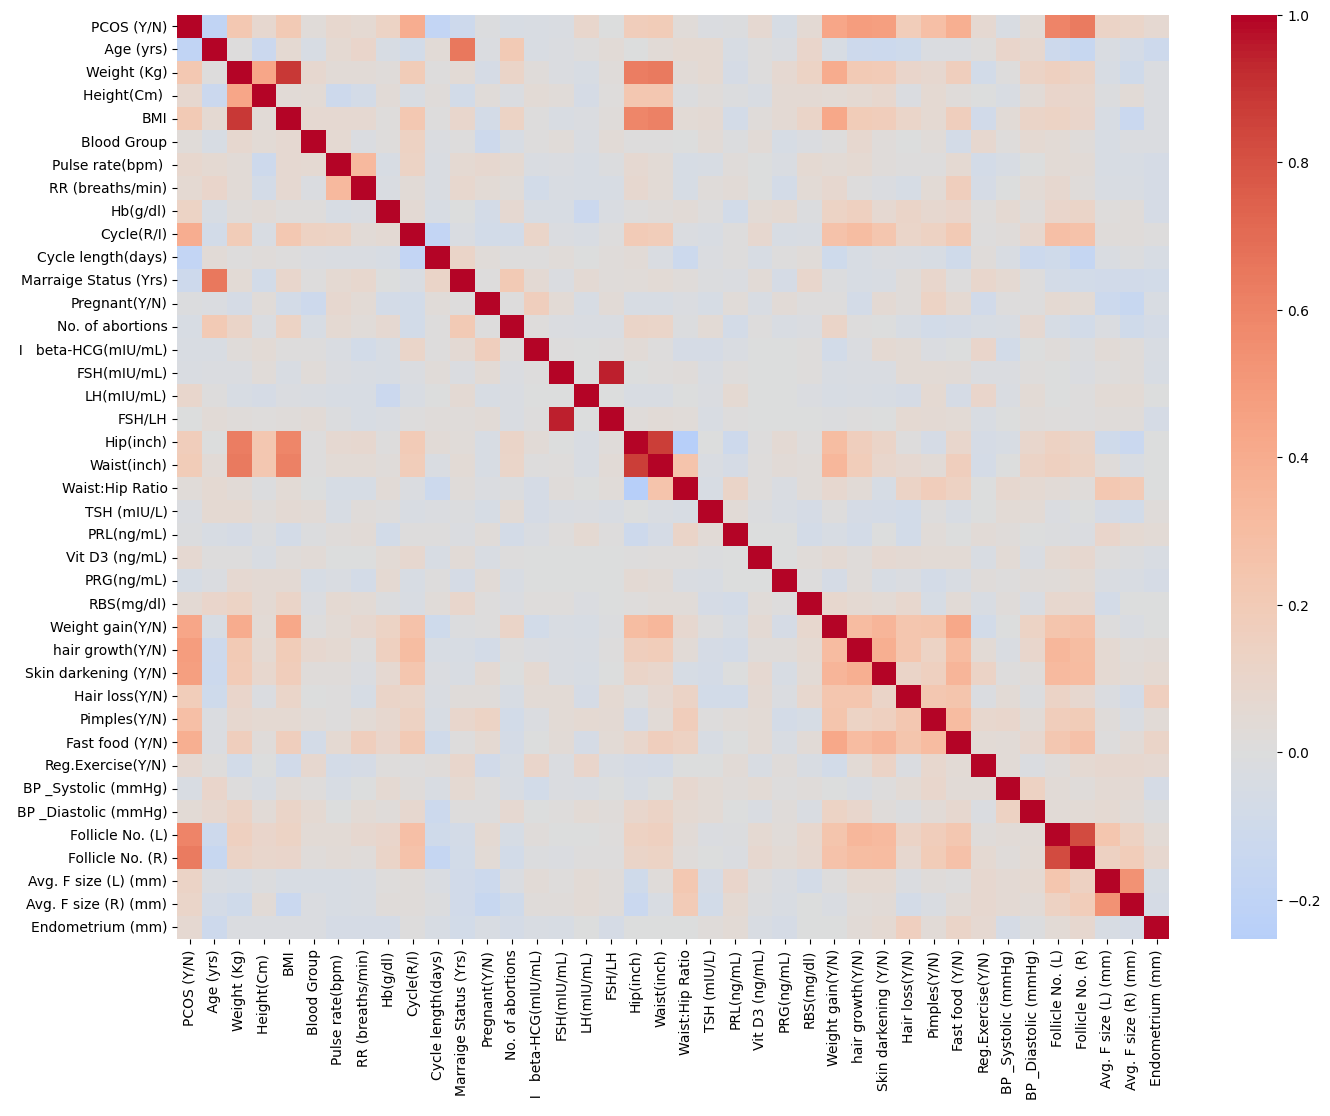

In [ ]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm',
    center=0
)

plt.show()

Removed redundant/derived input variables and the blood-group feature. BMI, FSH/LH, and Waist:Hip Ratio were retained as more compact representations of the corresponding measurements.

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
drop_cols = [
    'FSH(mIU/mL)',
    'LH(mIU/mL)',
    'Waist(inch)',
    'Hip(inch)',
    'Weight (Kg)',
    'Height(Cm)',
    'Blood Group'
]

df = df.drop(columns=drop_cols, errors='ignore')

In [ ]:
print(df.columns.tolist())

['PCOS (Y/N)', 'Age (yrs)', 'BMI', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of abortions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH/LH', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)']


In [ ]:
!pip install -q ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 4.8 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="PCOS Disease Detection - EDA",
    explorative=True
)

profile.to_file("PCOS_EDA_Report.html")

/tmp/ipykernel_2472/3529464849.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 35/35 [00:00<00:00, 62.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
profile

MODEL TRAINING

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1989 entries, 0 to 1999
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PCOS (Y/N)              1989 non-null   int64  
 1   Age (yrs)               1989 non-null   int64  
 2   BMI                     1989 non-null   float64
 3   Pulse rate(bpm)         1989 non-null   int64  
 4   RR (breaths/min)        1989 non-null   int64  
 5   Hb(g/dl)                1989 non-null   float64
 6   Cycle(R/I)              1989 non-null   int64  
 7   Cycle length(days)      1989 non-null   int64  
 8   Marraige Status (Yrs)   1989 non-null   float64
 9   Pregnant(Y/N)           1989 non-null   int64  
 10  No. of abortions        1989 non-null   int64  
 11  I   beta-HCG(mIU/mL)    1989 non-null   float64
 12  II    beta-HCG(mIU/mL)  1989 non-null   float64
 13  FSH/LH                  1989 non-null   float64
 14  Waist:Hip Ratio         1989 non-null   float

In [ ]:
print(df['II    beta-HCG(mIU/mL)'].unique()[:20])
print(df['AMH(ng/mL)'].unique()[:20])

['121.8' '418.9' '1.99' '9.35' '5.39' '523.6' '161.49' '177.58' '433.97'
 '236.5' '15' '54.08' '12' '4176' '278.32' '491.85' '100.2' '728.01'
 '232.64' '528.5']
['5.76' '3.09' '1.61' '7.3' '1.01' '0.9' '5.1' '5.4' '10.53' '2.26' '2.01'
 '5.6' '5.8' '1.8' '1.2' '9.1' '4.27' '11.48' '2' '12.8']


In [ ]:
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(
    df['II    beta-HCG(mIU/mL)'],
    errors='coerce'
)

df['AMH(ng/mL)'] = pd.to_numeric(
    df['AMH(ng/mL)'],
    errors='coerce'
)

In [ ]:
print(df[['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']].isnull().sum())

II    beta-HCG(mIU/mL)    5
AMH(ng/mL)                3
dtype: int64


In [ ]:
df.isnull().sum()

,0
PCOS (Y/N),0
Age (yrs),0
BMI,0
Pulse rate(bpm),0
RR (breaths/min),0
Hb(g/dl),0
Cycle(R/I),0
Cycle length(days),0
Marraige Status (Yrs),0
Pregnant(Y/N),0


In [ ]:
df  = df.dropna()

In [ ]:
X  =  df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "SVC": SVC(random_state=42)
}

In [ ]:
def evaluate_models(models, X_train, X_test, y_train, y_test):

    results = {}

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)

        results[name] = {
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "Confusion Matrix": cm
        }





    return results

In [ ]:
results = evaluate_models(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

In [ ]:
results

{'Logistic Regression': {'Accuracy': 0.9321608040201005,
  'Precision': 0.918918918918919,
  'Recall': 0.85,
  'Confusion Matrix': array([[269,   9],
         [ 18, 102]])},
 'Random Forest': {'Accuracy': 0.9899497487437185,
  'Precision': 1.0,
  'Recall': 0.9666666666666667,
  'Confusion Matrix': array([[278,   0],
         [  4, 116]])},
 'SVC': {'Accuracy': 0.9748743718592965,
  'Precision': 0.9910714285714286,
  'Recall': 0.925,
  'Confusion Matrix': array([[277,   1],
         [  9, 111]])}}

Hyperparameter tunning

In [ ]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 9.0 MB/s eta 0:00:00


In [ ]:
import optuna
from sklearn.model_selection import cross_val_score

In [ ]:
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical(
            'max_features', ['sqrt', 'log2', None]
        ),
        'bootstrap': trial.suggest_categorical(
            'bootstrap', [True, False]
        ),
        'criterion': trial.suggest_categorical(
            'criterion', ['gini', 'entropy', 'log_loss']
        )
    }

    model = RandomForestClassifier(
        **params,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    ).mean()

    return score

In [ ]:
study = optuna.create_study(direction='maximize')

study.optimize(
    objective,
    n_trials=100
)

[I 2026-09-13 11:10:49,373] A new study created in memory with name: no-name-9421a036-ab1f-4326-825b-1f0e8d9fd024
[I 2026-09-13 11:11:04,336] Trial 0 finished with value: 0.9654324638709806 and parameters: {'n_estimators': 482, 'max_depth': 17, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9654324638709806.
[I 2026-09-13 11:11:09,195] Trial 1 finished with value: 0.9541235385737663 and parameters: {'n_estimators': 325, 'max_depth': 6, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9654324638709806.
[I 2026-09-13 11:11:22,707] Trial 2 finished with value: 0.9685810610989531 and parameters: {'n_estimators': 285, 'max_depth': 16, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True, 'criterion': 'entropy'}. Best is trial 2 with value: 0.9685810610989531.
[I 20

In [ ]:
print("Best Accuracy:", study.best_value)
print("Best Parameters:")
print(study.best_params)

Best Accuracy: 0.9937166065337827
Best Parameters:
{'n_estimators': 123, 'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'gini'}


In [ ]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train) #final model

RandomForestClassifier(bootstrap=False, max_depth=30, min_samples_split=8,
                       n_estimators=123, n_jobs=-1, random_state=42)

In [ ]:
y_pred = best_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.9899497487437185
Precision: 1.0
Recall   : 0.9666666666666667

Confusion Matrix:
[[278   0]
 [  4 116]]


Downloading model

In [ ]:
import joblib

In [ ]:
joblib.dump(best_rf, 'pcos_random_forest.pkl')


['pcos_random_forest.pkl']

In [ ]:
joblib.dump(scaler, 'pcos_scaler.pkl')

['pcos_scaler.pkl']